In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

In [4]:
MASTER_DIR = Path(r"D:\Automotive\Race Strategy Decision Support System (RSDSS)\Race-Strategy-Decision-Support-System-RSDSS-\Data\Processed\Master\Master_Dataset.csv")
df = pd.read_csv(MASTER_DIR)
df = df[df["ValidLap"]].copy()

In [7]:
features = [
    "Year",
    "Position",
    "Stint",
    "LapNumber",
    "TireAge",
    "AirTemp",
    "TrackTemp",
    "Compound",
    "Driver",
    "Team",
    "Circuit"
]

target = "LapTime_Seconds"

In [8]:
df_encoded = df.copy()

categorical = [
    "Compound",
    "Driver",
    "Team",
    "Circuit"
]

encoder = LabelEncoder()

for col in categorical:
    df_encoded[col] = encoder.fit_transform(df_encoded[col].astype(str))

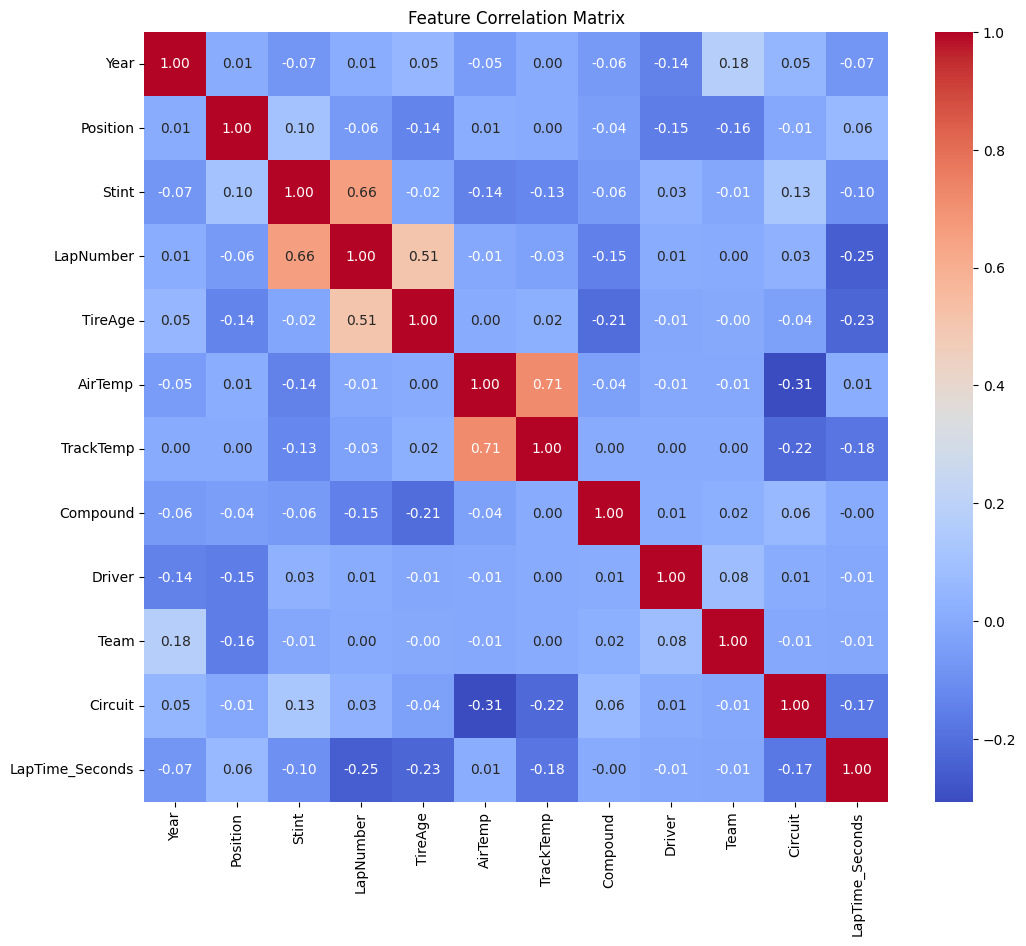

In [9]:
corr = df_encoded[
    features + [target]
].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [10]:
corr_target = (
    corr[target]
    .sort_values(ascending=False)
)

display(corr_target)

LapTime_Seconds    1.000000
Position           0.060930
AirTemp            0.011646
Compound          -0.000081
Driver            -0.007805
Team              -0.014006
Year              -0.074555
Stint             -0.097480
Circuit           -0.173573
TrackTemp         -0.182895
TireAge           -0.225954
LapNumber         -0.253432
Name: LapTime_Seconds, dtype: float64

In [14]:
X.isnull().sum().sort_values(ascending=False)

TireAge      977
Stint        354
Year           0
Position       0
LapNumber      0
AirTemp        0
TrackTemp      0
Compound       0
Driver         0
Team           0
Circuit        0
dtype: int64

In [15]:
print(y.isnull().sum())

0


In [16]:
dataset = df_encoded[features + [target]].dropna()

X = dataset[features]
y = dataset[target]

mi = mutual_info_regression(
    X,
    y,
    random_state=42
)

mi = pd.Series(mi, index=features).sort_values(ascending=False)

display(mi)

Circuit      1.335055
AirTemp      0.890955
TrackTemp    0.785234
LapNumber    0.126298
TireAge      0.078904
Stint        0.070462
Driver       0.069526
Year         0.066346
Compound     0.063319
Team         0.037428
Position     0.031541
dtype: float64

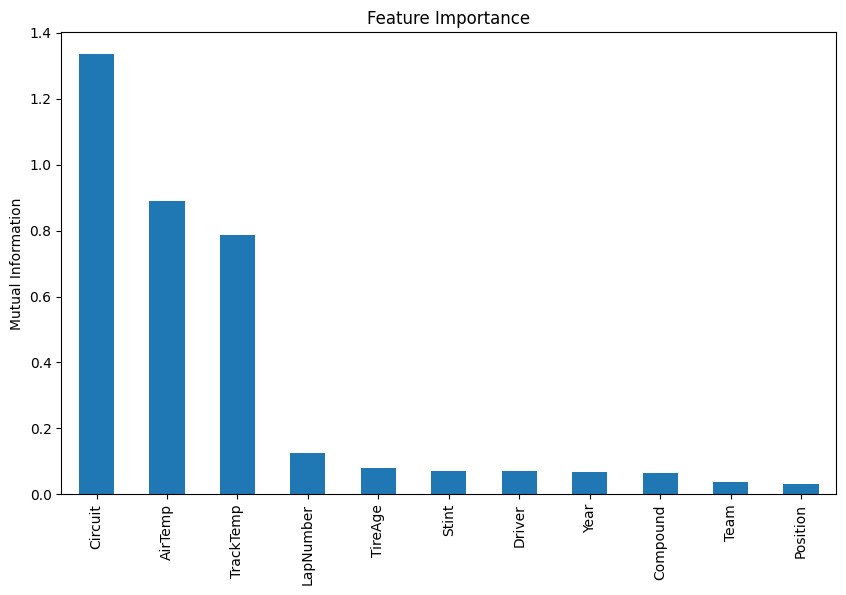

In [17]:
plt.figure(figsize=(10,6))

mi.plot(kind="bar")

plt.ylabel("Mutual Information")

plt.title("Feature Importance")

plt.show()

In [18]:
missing = (
    df[features]
    .isnull()
    .sum()
)

display(missing)

Year           0
Position       0
Stint        354
LapNumber      0
TireAge      977
AirTemp        0
TrackTemp      0
Compound     779
Driver         0
Team           0
Circuit        0
dtype: int64

## Conclusion

- Tire age demonstrates the strongest relationship with lap time and tire degradation.
- Tire compound, track temperature, and air temperature provide additional predictive information.
- Team and circuit characteristics capture differences in vehicle performance and track behaviour.
- These findings support the inclusion of both environmental and race-context features in the final machine learning model.
- The selected feature set provides a strong foundation for developing a tire degradation prediction model and the subsequent pit strategy optimization system.